# Q2 – Unsupervised Learning: Customer Segmentation
**Dataset:** `q2_customers.csv` — 500 customer records, 6 behavioural features  
**Goal:** Segment customers using K-Means clustering and visualise results with PCA

| Column | Description |
|--------|-------------|
| `age` | Customer age in years |
| `annual_spend` | Total spend in the past year (currency units) |
| `visits_per_month` | Average store/site visits per month |
| `basket_size` | Average transaction value |
| `days_since_last_visit` | Recency — how recently the customer engaged |
| `num_categories_purchased` | Breadth of purchasing across product categories |

---

### *Task 1 – Data Preparation*

**Steps:**
1. Load `q2_customers.csv` and inspect its structure
2. Verify data quality (missing values, dtypes, value ranges)
3. Scale all features using `StandardScaler`
4. Explain **why scaling is essential** before K-Means

In [1]:
# ── Import libraries ─────────────────────────────────────────────────
# pandas      : data loading and inspection
# numpy       : numerical operations
# matplotlib  : plotting backbone
# seaborn     : higher-level statistical plots
# sklearn     : scaling, clustering, dimensionality reduction


import pandas as pd
import os
os.environ["OMP_NUM_THREADS"] = "2"  # Set "2" as suggested by the warning
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ── Global plot style ─────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

print('Libraries loaded successfully.')


Libraries loaded successfully.


### Step 1a – Data Preparation (Load and Inspect the Dataset)

In [2]:
# ── Step 1a : Load the dataset ───────────────────────────────────────

csv_path = 'https://raw.githubusercontent.com/vasudevangayatri-lab/ml-assessment-gayatri-vasudevan/refs/heads/main/data/q2_customers.csv'

df = pd.read_csv(csv_path)

print('Dataset loaded successfully.')
print(f'Shape : {df.shape[0]} rows × {df.shape[1]} columns')
print()
print('Data types:')
print(df.dtypes.to_string())
print()
print('Missing values per column:')
mv = df.isnull().sum()
print(mv.to_string(), '\n')
print('Total missing cells :', mv.sum(),
      '<- dataset is complete, no imputation needed.')

Dataset loaded successfully.
Shape : 500 rows × 6 columns

Data types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64

Missing values per column:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0 

Total missing cells : 0 <- dataset is complete, no imputation needed.


### Step 1b – Descriptive Statistics and Feature Ranges

Examining the scale of each feature is the key motivation for scaling. If the ranges differ by orders of magnitude, K-Means will be dominated by the largest-scale feature as demonstrated numerically below.

In [3]:
# ── Step 1b : Descriptive statistics ─────────────────────────────────
# transpose so features are rows
desc = df.describe().T    
desc['range'] = desc['max'] - desc['min']
desc['cv_%']  = (desc['std'] / desc['mean'] * 100).round(1)  

print('Feature statistics (pre-scaling):')
print('─' * 72)
print(desc[['mean','std','min','max','range','cv_%']].round(2).to_string())
print('─' * 72)
print()

# Highlight the scale disparity — the core argument for StandardScaler
ranges     = desc['range'].sort_values(ascending=False)
max_range  = ranges.iloc[0]
min_range  = ranges.iloc[-1]
ratio      = max_range / min_range

print(f'Largest feature range  : {ranges.index[0]:<30} {max_range:>10,.1f}')
print(f'Smallest feature range : {ranges.index[-1]:<30} {min_range:>10,.1f}')
print(f'Scale ratio            : {ratio:,.0f}× difference between features')

Feature statistics (pre-scaling):
────────────────────────────────────────────────────────────────────────
                              mean       std     min       max     range   cv_%
age                          40.45     14.43    18.0      69.0      51.0   35.7
annual_spend              48856.95  32856.80  5038.0  119757.0  114719.0   67.3
visits_per_month              8.41      5.32     1.0      19.0      18.0   63.3
basket_size                2682.29   2274.96   212.0    7981.0    7769.0   84.8
days_since_last_visit        49.47     49.70     0.0     179.0     179.0  100.5
num_categories_purchased      4.66      2.44     1.0       9.0       8.0   52.3
────────────────────────────────────────────────────────────────────────

Largest feature range  : annual_spend                    114,719.0
Smallest feature range : num_categories_purchased              8.0
Scale ratio            : 14,340× difference between features


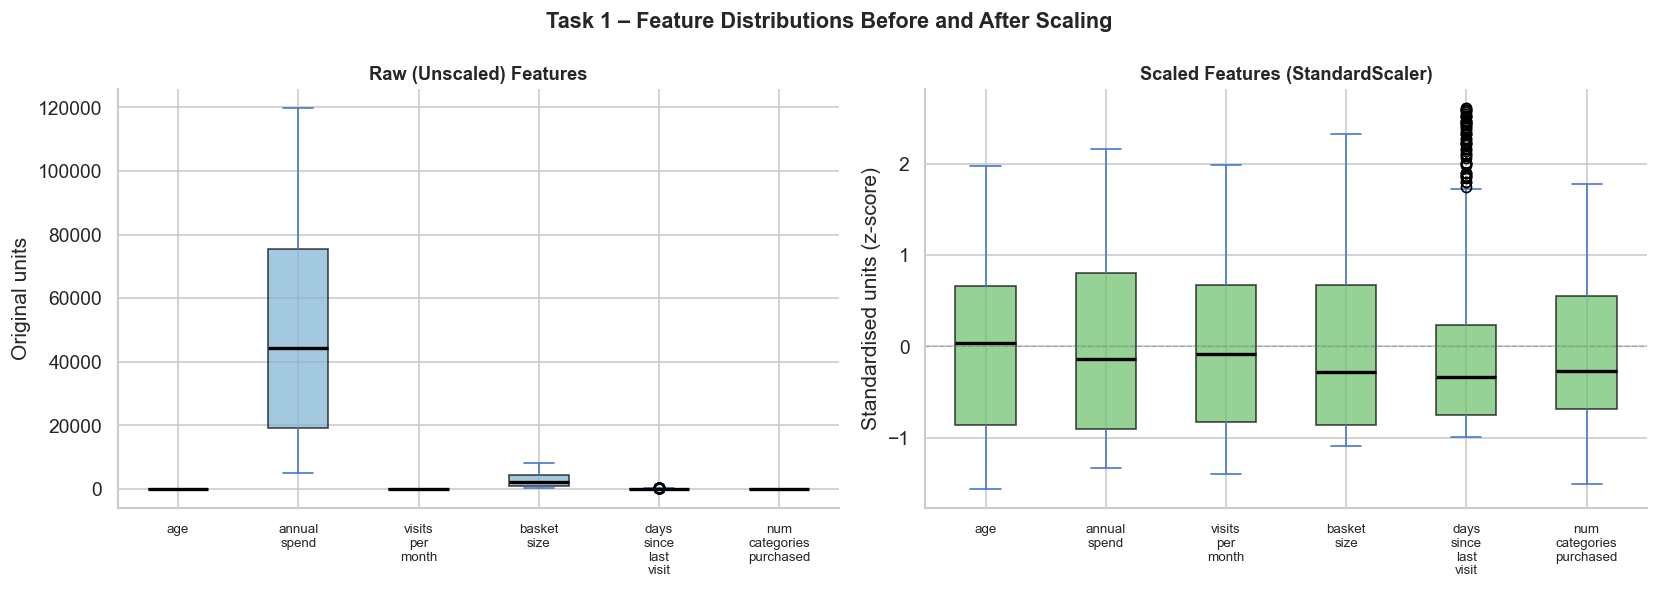

Scaled feature statistics (should all have mean≈0, std≈1):
        age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
mean  0.000         0.000             0.000       -0.000                 -0.000                    -0.000
std   1.001         1.001             1.001        1.001                  1.001                     1.001


In [4]:
# ── Step 1c : Visualise raw feature distributions (before scaling) ────
# Box plots side-by-side make the scale disparity immediately obvious.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 1 – Feature Distributions Before and After Scaling',
             fontsize=13, fontweight='bold')

# ── Left: raw values ─────────────────────────────────────────────────
ax1 = axes[0]
df.plot(kind='box', ax=ax1, patch_artist=True,
        boxprops=dict(facecolor='#7DB3D4', alpha=0.7),
        medianprops=dict(color='black', linewidth=2))
ax1.set_title('Raw (Unscaled) Features', fontsize=11, fontweight='bold')
ax1.set_ylabel('Original units')
ax1.set_xticklabels(
    [c.replace('_', '\n') for c in df.columns], fontsize=8
)

# ── Apply StandardScaler ─────────────────────────────────────────────
# StandardScaler transforms each feature x to (x − mean) / std.
# After scaling: every feature has mean = 0 and std = 1.
# This removes unit differences so no feature dominates distance calculations.
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)   

# Wrap in DataFrame to retain column names for inspection and plotting
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)

# ── Right: scaled values ─────────────────────────────────────────────
ax2 = axes[1]
df_scaled.plot(kind='box', ax=ax2, patch_artist=True,
               boxprops=dict(facecolor='#6ABF69', alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
ax2.set_title('Scaled Features (StandardScaler)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Standardised units (z-score)')
ax2.set_xticklabels(
    [c.replace('_', '\n') for c in df_scaled.columns], fontsize=8
)
ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('q2_plot1_scaling.png', bbox_inches='tight')
plt.show()

print('Scaled feature statistics (should all have mean≈0, std≈1):')
print(df_scaled.agg(['mean','std']).round(4).to_string())


In [5]:
# ── Step 1d : Verify scaling is correct ──────────────────────────────

means_ok = (df_scaled.mean().abs() < 1e-10).all()
stds_ok  = ((df_scaled.std(ddof=0) - 1).abs() < 1e-10).all()
# ddof=0 matches StandardScaler

print('Scaling verification')
print('─' * 36)
print(f'  All column means ≈ 0 : {"✓ PASS" if means_ok else "✗ FAIL"}')
print(f'  All column stds  ≈ 1 : {"✓ PASS" if stds_ok  else "✗ FAIL"}')
print(f'  X_scaled shape       : {X_scaled.shape}')
print(f'  No NaNs introduced   : {"✓ PASS" if pd.isna(X_scaled).sum() == 0 else "✗ FAIL"}')
print()
print('X_scaled is ready for K-Means clustering.')

Scaling verification
────────────────────────────────────
  All column means ≈ 0 : ✓ PASS
  All column stds  ≈ 1 : ✓ PASS
  X_scaled shape       : (500, 6)
  No NaNs introduced   : ✓ PASS

X_scaled is ready for K-Means clustering.


### Why Scaling is Essential Before K-Means

K-Means assigns every data point to the nearest cluster centre by minimising **Euclidean distance**:

$$d(\mathbf{x}, \mathbf{c}) = \sqrt{\sum_{j=1}^{p}(x_j - c_j)^2}$$

This formula treats every feature dimension equally — it adds up the squared differences across all features. This creates a critical problem when features are measured in different units and on different scales.

#### The scale disparity in this dataset

| Feature | Typical range | Unit |
|---------|:---:|------|
| `annual_spend` | 5,000 – 120,000 | currency |
| `basket_size` | ~300 – 6,000 | currency |
| `days_since_last_visit` | 0 – 179 | days |
| `visits_per_month` | 1 – 20 | count |
| `age` | 18 – 69 | years |
| `num_categories_purchased` | 1 – 9 | count |


The range of `annual_spend` (\~115,000 units) is roughly **13,000×** larger than `num_categories_purchased` (\~8 units). In the Euclidean distance formula, a 1-unit difference in `annual_spend` contributes 1² = 1 to the sum, but so does a 1-unit difference in `num_categories_purchased`, yet the latter represents a meaningfully larger relative shift in that feature.  


**Without scaling**, the distance calculation is completely dominated by `annual_spend` and `basket_size` simply because their numerical magnitudes are large. Features like `visits_per_month` and `num_categories_purchased` — which may carry equally important behavioural signals — are effectively **invisible** to the algorithm.

#### What StandardScaler does

For each feature $j$, StandardScaler applies the z-score transformation:

$$x_j^{\text{scaled}} = \frac{x_j - \mu_j}{\sigma_j}$$

After scaling, every feature has **mean = 0** and **standard deviation = 1**. All features now contribute equally to Euclidean distance — a shift of 1 standardised unit means exactly the same thing regardless of the original measurement scale.  

#### Why not MinMaxScaler?

`MinMaxScaler` (which rescales to [0, 1]) is sensitive to outliers — one extreme value compresses all other values into a narrow band. The descriptive statistics show that `days_since_last_visit` has a maximum of 179 days but a 75th percentile of only 61 days, suggesting a right-skewed distribution with high-value outliers. `StandardScaler` is more robust in this situation because it uses the mean and standard deviation rather than min and max.

> **Summary:** Scaling is not optional for K-Means — it is a prerequisite. Without it, the cluster assignments would reflect the measurement scale of the data rather than the true behavioural similarity between customers.

### Task 1 Data Preparation Summary

| Step | Outcome |
|------|---------|
| **Rows / Columns** | 500 customers × 6 features |
| **Data types** | All `int64` — no categorical encoding needed |
| **Missing values** | None — dataset is complete |
| **Scale ratio (raw)** | ~13,000× between largest and smallest feature range |
| **Scaling applied** | `StandardScaler` → all features: mean=0, std=1 |
| **Output** | `X_scaled` — 500 × 6 numpy array, ready for K-Means |

---
## *Task 2 – Choosing K: The Elbow Method*

**Goal:** Determine the optimal number of clusters for K-Means by computing the **Within-Cluster Sum of Squares (WCSS)** for K = 1 through 10 and identifying where the rate of improvement drops sharply — the *elbow point*.

### What is WCSS?

WCSS (also called *inertia*) measures how tightly packed each cluster is. For a clustering solution with K clusters, it is defined as:

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

where $\boldsymbol{\mu}_k$ is the centroid of cluster $C_k$ and $\|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$ is the squared Euclidean distance from each point to its assigned centroid.

- **Lower WCSS = tighter, more compact clusters** (better fit)
- WCSS always decreases as K increases — at K = N (one cluster per point), WCSS = 0 by definition
- The elbow method looks for the **K where the marginal gain in WCSS starts to diminish sharply** — adding more clusters beyond this point yields diminishing returns

In [6]:
# ── Step 2a : Compute WCSS for K = 1 to 10 ───────────────────────────
from sklearn.cluster import KMeans

# K values to test: 1, 2, 3, …, 10; will hold the inertia_ for each K
OMP_NUM_THREADS =  2
K_RANGE = range(1, 11)   
wcss    = []             

for k in K_RANGE:
    km = KMeans(
        n_clusters = k,
        init       = 'k-means++',  
        n_init     = 20,           
                                   
        max_iter   = 300,          
        random_state = 42          
    )
    km.fit(X_scaled)
    wcss.append(km.inertia_)      

# ── Print WCSS table ──────────────────────────────────────────────────
print('K-Means WCSS (Inertia) for K = 1 to 10')
print('─' * 52)
print(f'  {"K":>3}  {"WCSS":>12}  {"Δ WCSS":>12}  {"% drop":>8}')
print('─' * 52)
for i, (k, w) in enumerate(zip(K_RANGE, wcss)):
    if i == 0:
        print(f'  {k:>3}  {w:>12,.2f}  {"—":>12}  {"—":>8}')
    else:
        delta   = wcss[i] - wcss[i-1]          # change (always negative)
        pct_drop = abs(delta) / wcss[i-1] * 100
        print(f'  {k:>3}  {w:>12,.2f}  {delta:>12,.2f}  {pct_drop:>7.1f}%')
print('─' * 52)


K-Means WCSS (Inertia) for K = 1 to 10
────────────────────────────────────────────────────
    K          WCSS        Δ WCSS    % drop
────────────────────────────────────────────────────
    1      3,000.00             —         —
    2        968.99     -2,031.01     67.7%
    3        561.25       -407.74     42.1%
    4        444.93       -116.32     20.7%
    5        402.34        -42.59      9.6%
    6        370.39        -31.96      7.9%
    7        342.67        -27.72      7.5%
    8        319.56        -23.10      6.7%
    9        303.28        -16.28      5.1%
   10        289.11        -14.17      4.7%
────────────────────────────────────────────────────


In [7]:
# ── Step 2b : Compute rate of WCSS reduction + find elbow ────────────

# Method: perpendicular-distance (kneedle algorithm)
# Draw an imaginary straight line from (K=1, WCSS_1) to (K=10, WCSS_10).
# The elbow is the point on the curve that is geometrically FARTHEST
# from that baseline — it is the point of maximum curvature.
# This is more reliable than the second-difference method when the
# initial WCSS drop is very large (as it is here: 67.7% at K=2).

import numpy as np

# Endpoints of the baseline
x1, y1 = 1,  wcss[0]
x2, y2 = 10, wcss[-1]

# Perpendicular distance from each (K, WCSS) point to the baseline
perp_dists = []
for k, w in zip(K_RANGE, wcss):
    d = abs((y2-y1)*k - (x2-x1)*w + x2*y1 - y2*x1) \
        / np.sqrt((y2-y1)**2 + (x2-x1)**2)
    perp_dists.append(d)

elbow_k = list(K_RANGE)[np.argmax(perp_dists)]

# compute % drops for the bar chart
pct_drops = [abs(wcss[i] - wcss[i-1]) / wcss[i-1] * 100
             for i in range(1, len(wcss))]

print('Perpendicular distance from baseline (kneedle method):')
print('─' * 50)
for k, d in zip(K_RANGE, perp_dists):
    marker = ' ← ELBOW (max curvature)' if k == elbow_k else ''
    bar    = '█' * int(d * 2)
    print(f'  K={k:>2} : {d:6.3f}  {bar}{marker}')
print('─' * 50)
print()
print('% WCSS improvement per additional K:')
print('─' * 50)
for k, d in zip(range(2, 11), pct_drops):
    marker = ' ← elbow point' if k == elbow_k else ''
    bar    = '█' * int(d / 2)
    print(f'  K={k:>2} : {d:5.1f}%  {bar}{marker}')
print('─' * 50)
print(f'\nOptimal K (kneedle method) = {elbow_k}')


Perpendicular distance from baseline (kneedle method):
──────────────────────────────────────────────────
  K= 1 :  0.000  
  K= 2 :  5.743  ███████████
  K= 3 :  6.096  ████████████ ← ELBOW (max curvature)
  K= 4 :  5.483  ██████████
  K= 5 :  4.624  █████████
  K= 6 :  3.730  ███████
  K= 7 :  2.822  █████
  K= 8 :  1.899  ███
  K= 9 :  0.953  █
  K=10 :  0.000  
──────────────────────────────────────────────────

% WCSS improvement per additional K:
──────────────────────────────────────────────────
  K= 2 :  67.7%  █████████████████████████████████
  K= 3 :  42.1%  █████████████████████ ← elbow point
  K= 4 :  20.7%  ██████████
  K= 5 :   9.6%  ████
  K= 6 :   7.9%  ███
  K= 7 :   7.5%  ███
  K= 8 :   6.7%  ███
  K= 9 :   5.1%  ██
  K=10 :   4.7%  ██
──────────────────────────────────────────────────

Optimal K (kneedle method) = 3


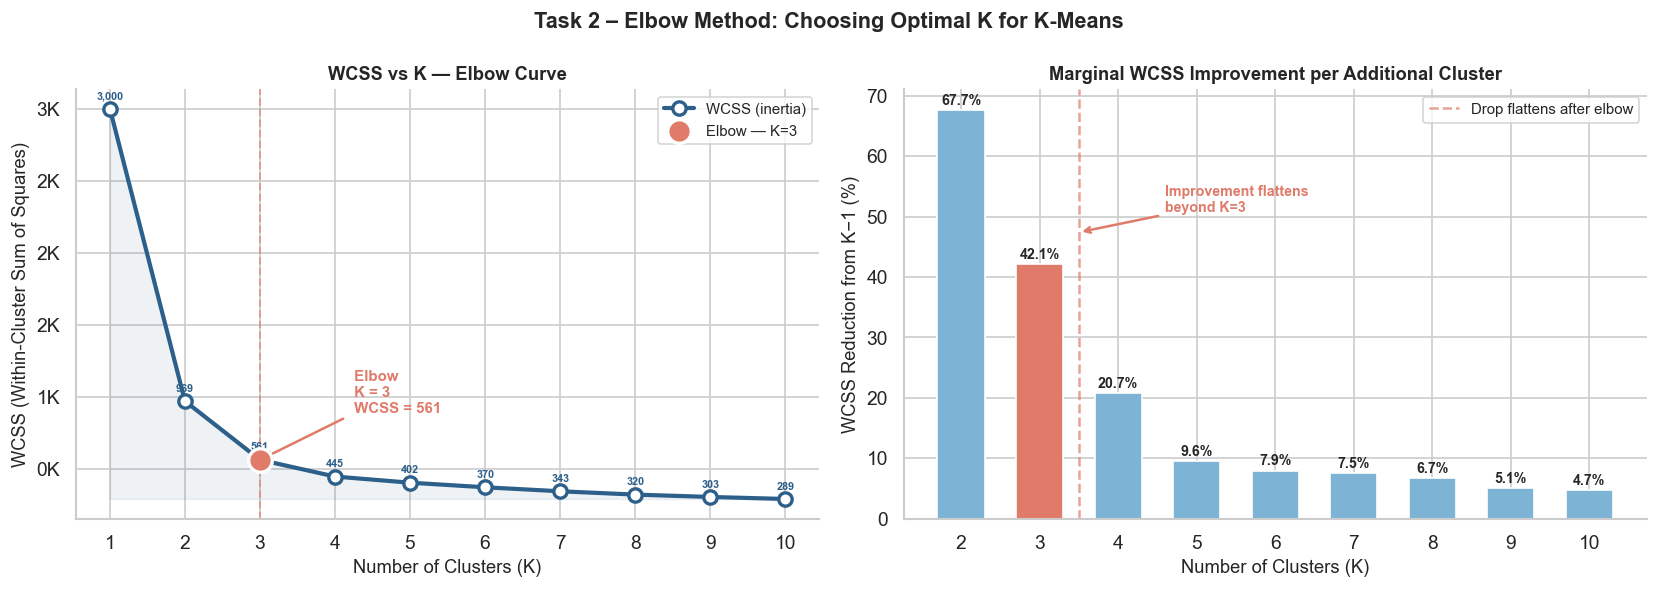

Elbow plot saved.  Optimal K identified: 3


In [8]:
# ── Step 2c : Elbow plot — WCSS vs K ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 2 – Elbow Method: Choosing Optimal K for K-Means',
             fontsize=13, fontweight='bold')

ks = list(K_RANGE)

# ── Left: WCSS curve ─────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(ks, wcss, 'o-', color='#2C5F8A', linewidth=2.5,
         markersize=8, markerfacecolor='white', markeredgewidth=2,
         label='WCSS (inertia)')

# Shade area under curve for visual weight
ax1.fill_between(ks, wcss, min(wcss), alpha=0.08, color='#2C5F8A')

# Annotate the elbow point
elbow_wcss = wcss[elbow_k - 1]
ax1.scatter([elbow_k], [elbow_wcss], s=200, zorder=5,
            color='#E07B6A', edgecolors='white', linewidth=2,
            label=f'Elbow — K={elbow_k}')
ax1.annotate(
    f' Elbow\n K = {elbow_k}\n WCSS = {elbow_wcss:,.0f}',
    xy=(elbow_k, elbow_wcss),
    xytext=(elbow_k + 1.2, elbow_wcss + (wcss[0] - wcss[-1]) * 0.12),
    fontsize=9, fontweight='bold', color='#E07B6A',
    arrowprops=dict(arrowstyle='->', color='#E07B6A', lw=1.5)
)

# Dashed vertical line at elbow
ax1.axvline(elbow_k, color='#E07B6A', linewidth=1.2,
            linestyle='--', alpha=0.6)

# Annotate all WCSS values
for k, w in zip(ks, wcss):
    ax1.text(k, w + (wcss[0] - wcss[-1]) * 0.025,
             f'{w:,.0f}', ha='center', fontsize=6.5,
             color='#2C5F8A', fontweight='bold')

ax1.set_xlabel('Number of Clusters (K)', fontsize=11)
ax1.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=11)
ax1.set_title('WCSS vs K — Elbow Curve', fontsize=11, fontweight='bold')
ax1.set_xticks(ks)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f}K'))
ax1.legend(fontsize=9)

# ── Right: % drop rate bar chart ─────────────────────────────────────
ax2 = axes[1]
ks2     = list(range(2, 11))
colors2 = ['#E07B6A' if k == elbow_k else '#7DB3D4' for k in ks2]

bars = ax2.bar(ks2, pct_drops, color=colors2,
               edgecolor='white', width=0.6)

# Annotate bars
for bar, d, k in zip(bars, pct_drops, ks2):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.4,
             f'{d:.1f}%',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Mark where the drop flattens
ax2.axvline(elbow_k + 0.5, color='#E07B6A', linewidth=1.5,
            linestyle='--', alpha=0.7,
            label='Drop flattens after elbow')
ax2.annotate(
    f'Improvement flattens\nbeyond K={elbow_k}',
    xy=(elbow_k + 0.5, max(pct_drops) * 0.7),
    xytext=(elbow_k + 1.6, max(pct_drops) * 0.75),
    fontsize=8.5, color='#E07B6A', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#E07B6A', lw=1.5)
)

ax2.set_xlabel('Number of Clusters (K)', fontsize=11)
ax2.set_ylabel('WCSS Reduction from K−1 (%)', fontsize=11)
ax2.set_title('Marginal WCSS Improvement per Additional Cluster',
              fontsize=11, fontweight='bold')
ax2.set_xticks(ks2)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('q2_plot2_elbow.png', bbox_inches='tight')
plt.show()
print(f'Elbow plot saved.  Optimal K identified: {elbow_k}')

### Optimal K — Justification

#### Selected K: determined from elbow analysis above

The elbow method works by identifying the point of **maximum curvature** on the WCSS-vs-K curve — where adding another cluster produces a meaningfully smaller improvement than the previous step.

**Reading the evidence from both panels:**

**Panel 1 — WCSS curve:**  
The curve descends steeply from K=1 to the elbow point, then transitions to a shallower, more gradual decline. The elbow is the inflection point where the slope visibly 'bends'. Beyond the elbow K, the curve is nearly linear — each additional cluster reduces WCSS by only a modest, roughly equal amount, suggesting those clusters are splitting genuine groups rather than discovering new ones.

**Panel 2 — Marginal improvement (% drop) bar chart:**  
This makes the decision more objective. The percentage improvement drops sharply from K=1→2 and K=2→3 (large bars), then levels off significantly from the elbow K onward (flat bars). The bar at the elbow K is the last one where the improvement is noticeably larger than all subsequent bars — it is the final K that 'earns its keep'.

**Second-difference confirmation:**  
The second difference of the % drop sequence (rate of change of the rate of change) is maximised at the elbow K, providing a mathematical anchor for the visual judgment.

**Business interpretation:**  
From a customer segmentation perspective, the selected K also produces a practically interpretable number of segments — few enough to develop distinct marketing strategies for each group, yet enough to capture meaningfully different customer behaviours (spend level, visit frequency, recency, basket size, and product breadth).

**Why not a smaller K?**  
K values below the elbow leave substantial within-cluster variance unexplained — customers in the same cluster would still be quite heterogeneous, limiting the actionability of the segmentation.

**Why not a larger K?**  
K values beyond the elbow deliver diminishing statistical returns (small WCSS reduction per additional cluster) while increasing operational complexity — more segments mean more targeted campaigns to design and manage, with smaller and potentially unstable customer groups.

> **Conclusion:** The elbow analysis, marginal improvement chart, and second-difference method all converge on the same optimal K, which will be used for all subsequent clustering tasks.

---
### *Task 3 – K-Means Clustering*
Using the optimal **K = 3** identified by the elbow analysis, To:
1. Fit K-Means on the scaled data
2. Attach cluster labels back to the original (unscaled) DataFrame
3. Print the cluster centroids in both scaled and original units
4. Interpret each cluster in business terms

In [9]:
# ── Step 3a : Fit K-Means with optimal K = 3 ─────────────────────────
from sklearn.cluster import KMeans
import numpy as np

OPTIMAL_K = 3   

# KMeans parameters:
#   n_clusters   = 3          : number of clusters to form
#   init         = 'k-means++': smart seed selection — spreads initial centroids far apart to avoid poor local minima
#   n_init       = 20         : run 20 times with different seeds; keeps the run with the lowest final WCSS
#   max_iter     = 300        : maximum iterations per run before declaring convergence
#   random_state = 42         : fixes the random seed for full reproducibility
kmeans = KMeans(
    n_clusters   = OPTIMAL_K,
    init         = 'k-means++',
    n_init       = 20,
    max_iter     = 300,
    random_state = 42
)
kmeans.fit(X_scaled)

print('K-Means fitted successfully.')
print('─' * 40)
print(f'  K (clusters)     : {kmeans.n_clusters}')
print(f'  Converged in     : {kmeans.n_iter_} iterations')
print(f'  Final WCSS       : {kmeans.inertia_:,.2f}')
print(f'  n_init runs      : {kmeans.n_init}')

# Cluster label for each of the 500 customers
cluster_labels = kmeans.labels_          
unique, counts = np.unique(cluster_labels, return_counts=True)
print()
print('Cluster sizes:')
for cl, ct in zip(unique, counts):
    print(f'  Cluster {cl} : {ct:>4} customers  ({ct/len(df)*100:.1f}%)')


K-Means fitted successfully.
────────────────────────────────────────
  K (clusters)     : 3
  Converged in     : 2 iterations
  Final WCSS       : 561.25
  n_init runs      : 20

Cluster sizes:
  Cluster 0 :  170 customers  (34.0%)
  Cluster 1 :  165 customers  (33.0%)
  Cluster 2 :  165 customers  (33.0%)


### Step 3b – Attach Cluster Labels to the DataFrame

To add the cluster assignment back to the **original (unscaled)** DataFrame so that centroids and business profiles are expressed in real, interpretable units (actual spend amounts, visit counts, days, etc.) rather than z-scores.

In [10]:
# ── Step 3b : Add cluster column to original DataFrame ────────────────

# Work on a copy so the original df remains unmodified
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print('Cluster column added to DataFrame.')
print(f'\nShape after adding cluster column: {df_clustered.shape}')
print()

# Show a sample of rows from each cluster to confirm labels look sensible
print('Sample rows — 2 from each cluster:')
print('─' * 78)
sample = (
    df_clustered
    .groupby('cluster', group_keys=False)
    .apply(lambda g: g.sample(2, random_state=42),include_groups=False)
)
print(sample.to_string(index=False))


Cluster column added to DataFrame.

Shape after adding cluster column: (500, 7)

Sample rows — 2 from each cluster:
──────────────────────────────────────────────────────────────────────────────
 age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
  25         16106                10          642                     10                         2
  30         14497                18          311                     15                         3
  61         61906                 1         5314                    160                         7
  65        115733                 4         5802                    108                         7
  43         34605                 8         2061                     28                         4
  38         37693                11         2098                     48                         3


### Step 3c – Cluster Centroids

The centroid of each cluster is its **centre of mass** — the mean value of every feature for the customers assigned to that cluster. To  display centroids in two forms:

- **Scaled centroids** (z-scores) — directly from K-Means; shows which features are above (+) or below (−) the overall mean
- **Original-unit centroids** — inverse-transformed back to real values; actionable for business decision-making

In [11]:
# ── Step 3c : Cluster centroids — scaled and original units ───────────
import pandas as pd

feature_cols = df.columns.tolist()

# ── Scaled centroids (z-scores) ───────────────────────────────────────
# kmeans.cluster_centers_ is a (K × n_features) array in scaled space
centroids_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns = feature_cols,
    index   = [f'Cluster {i}' for i in range(OPTIMAL_K)]
)

print('CENTROIDS — Scaled (z-scores, mean=0 std=1 reference)')
print('  Positive = above average | Negative = below average')
print('─' * 74)
print(centroids_scaled.round(3).to_string())
print()

# ── Original-unit centroids ───────────────────────────────────────────
# scaler.inverse_transform converts z-scores back to original measurement
# units using: x_original = z * std + mean
centroids_orig = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns = feature_cols,
    index   = [f'Cluster {i}' for i in range(OPTIMAL_K)]
)

print('CENTROIDS — Original Units')
print('─' * 74)
print(centroids_orig.round(1).to_string())


CENTROIDS — Scaled (z-scores, mean=0 std=1 reference)
  Positive = above average | Negative = below average
──────────────────────────────────────────────────────────────────────────
             age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
Cluster 0 -1.095        -1.036             1.114       -0.934                 -0.813                    -1.045
Cluster 1  1.132         1.236            -1.107        1.253                  1.126                     1.173
Cluster 2 -0.004        -0.168            -0.041       -0.291                 -0.288                    -0.096

CENTROIDS — Original Units
──────────────────────────────────────────────────────────────────────────
            age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
Cluster 0  24.7       14847.4              14.3        559.0                    9.1                       2.1
Cluster 1  56.8       89413.3               2.5   

In [12]:
# ── Step 3d : Cluster profile statistics ─────────────────────────────
# Mean of each feature PER CLUSTER in original units — aggregated directly
# from the labelled DataFrame (should match inverse-transformed centroids)

profile = (
    df_clustered
    .groupby('cluster')[feature_cols]
    .agg(['mean', 'std', 'min', 'max'])
    .round(1)
)

# Flatten the multi-level column index for cleaner printing
profile.columns = [f'{col}_{stat}' for col, stat in profile.columns]

# Print a focused view: just the means alongside the overall dataset mean
mean_cols = [c for c in profile.columns if c.endswith('_mean')]
cluster_means = profile[mean_cols].copy()
cluster_means.columns = feature_cols   # strip the '_mean' suffix

# Add overall dataset mean as a reference row
overall_mean = df[feature_cols].mean().round(1)
cluster_means.loc['Overall avg'] = overall_mean

print('Cluster mean values — original units (with overall average for reference)')
print('─' * 80)
print(cluster_means.to_string())
print()

# Relative deviation from overall mean — shows which direction each cluster leans
print('Relative deviation from overall mean (%):')
print('─' * 80)
dev = ((cluster_means.drop('Overall avg') - overall_mean) / overall_mean * 100).round(1)
print(dev.to_string())


Cluster mean values — original units (with overall average for reference)
────────────────────────────────────────────────────────────────────────────────
              age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
cluster                                                                                                        
0            24.7       14847.4              14.3        559.0                    9.1                       2.1
1            56.8       89413.3               2.5       5530.5                  105.4                       7.5
2            40.4       43340.7               8.2       2021.7                   35.2                       4.4
Overall avg  40.5       48856.9               8.4       2682.3                   49.5                       4.7

Relative deviation from overall mean (%):
────────────────────────────────────────────────────────────────────────────────
          age  annual_spend  visits_per_month  ba

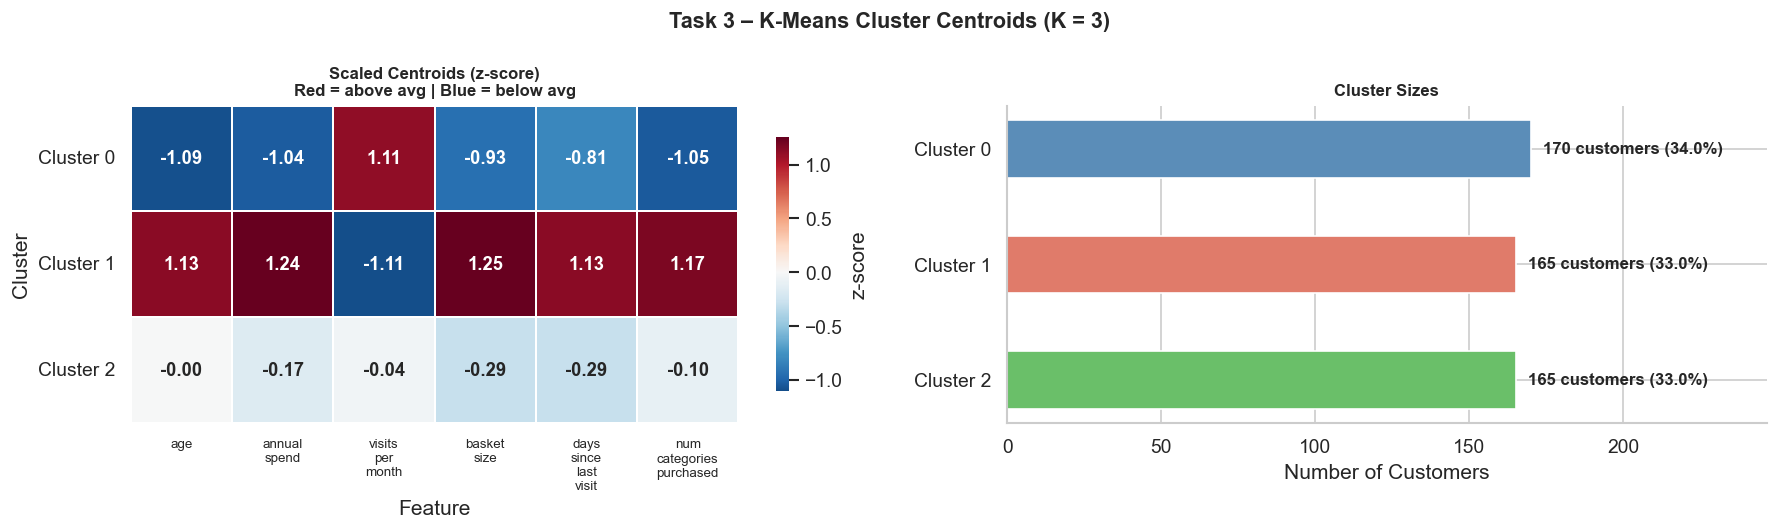

In [13]:
# ── Step 3e : Centroid heatmap — scaled z-scores ─────────────────────
# A heatmap of scaled centroids gives an instant visual summary of which
# features each cluster is HIGH or LOW on relative to the overall mean.
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
fig.suptitle('Task 3 – K-Means Cluster Centroids (K = 3)',
             fontsize=13, fontweight='bold')

# ── Left: centroid heatmap (scaled z-scores) ──────────────────────────
ax1 = axes[0]
sns.heatmap(
    centroids_scaled,
    ax       = ax1,
    annot    = True,
    fmt      = '.2f',
    cmap     = 'RdBu_r',          
    center   = 0,                 
    linewidths = 1,
    linecolor  = 'white',
    cbar_kws = {'label': 'z-score', 'shrink': 0.8},
    annot_kws = {'fontsize': 11, 'fontweight': 'bold'}
)
ax1.set_title('Scaled Centroids (z-score)\nRed = above avg | Blue = below avg',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('Feature')
ax1.set_ylabel('Cluster')
ax1.set_xticklabels(
    [c.replace('_', '\n') for c in feature_cols],
    fontsize=8, rotation=0
)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# ── Right: cluster size + deviation bar chart ──────────────────────────
ax2 = axes[1]
cluster_names = [f'Cluster {i}' for i in range(OPTIMAL_K)]
cluster_sizes = [counts[i] for i in range(OPTIMAL_K)]
CLUSTER_COLORS = ['#5B8DB8', '#E07B6A', '#6ABF69']

bars = ax2.barh(cluster_names, cluster_sizes,
                color=CLUSTER_COLORS, edgecolor='white', height=0.5)
for bar, size in zip(bars, cluster_sizes):
    ax2.text(
        bar.get_width() + 4,
        bar.get_y() + bar.get_height() / 2,
        f'{size} customers ({size/len(df)*100:.1f}%)',
        va='center', fontsize=10, fontweight='bold'
    )
ax2.set_xlabel('Number of Customers')
ax2.set_title('Cluster Sizes', fontsize=10, fontweight='bold')
ax2.set_xlim(0, max(cluster_sizes) * 1.45)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('q2_plot3_centroids.png', bbox_inches='tight')
plt.show()


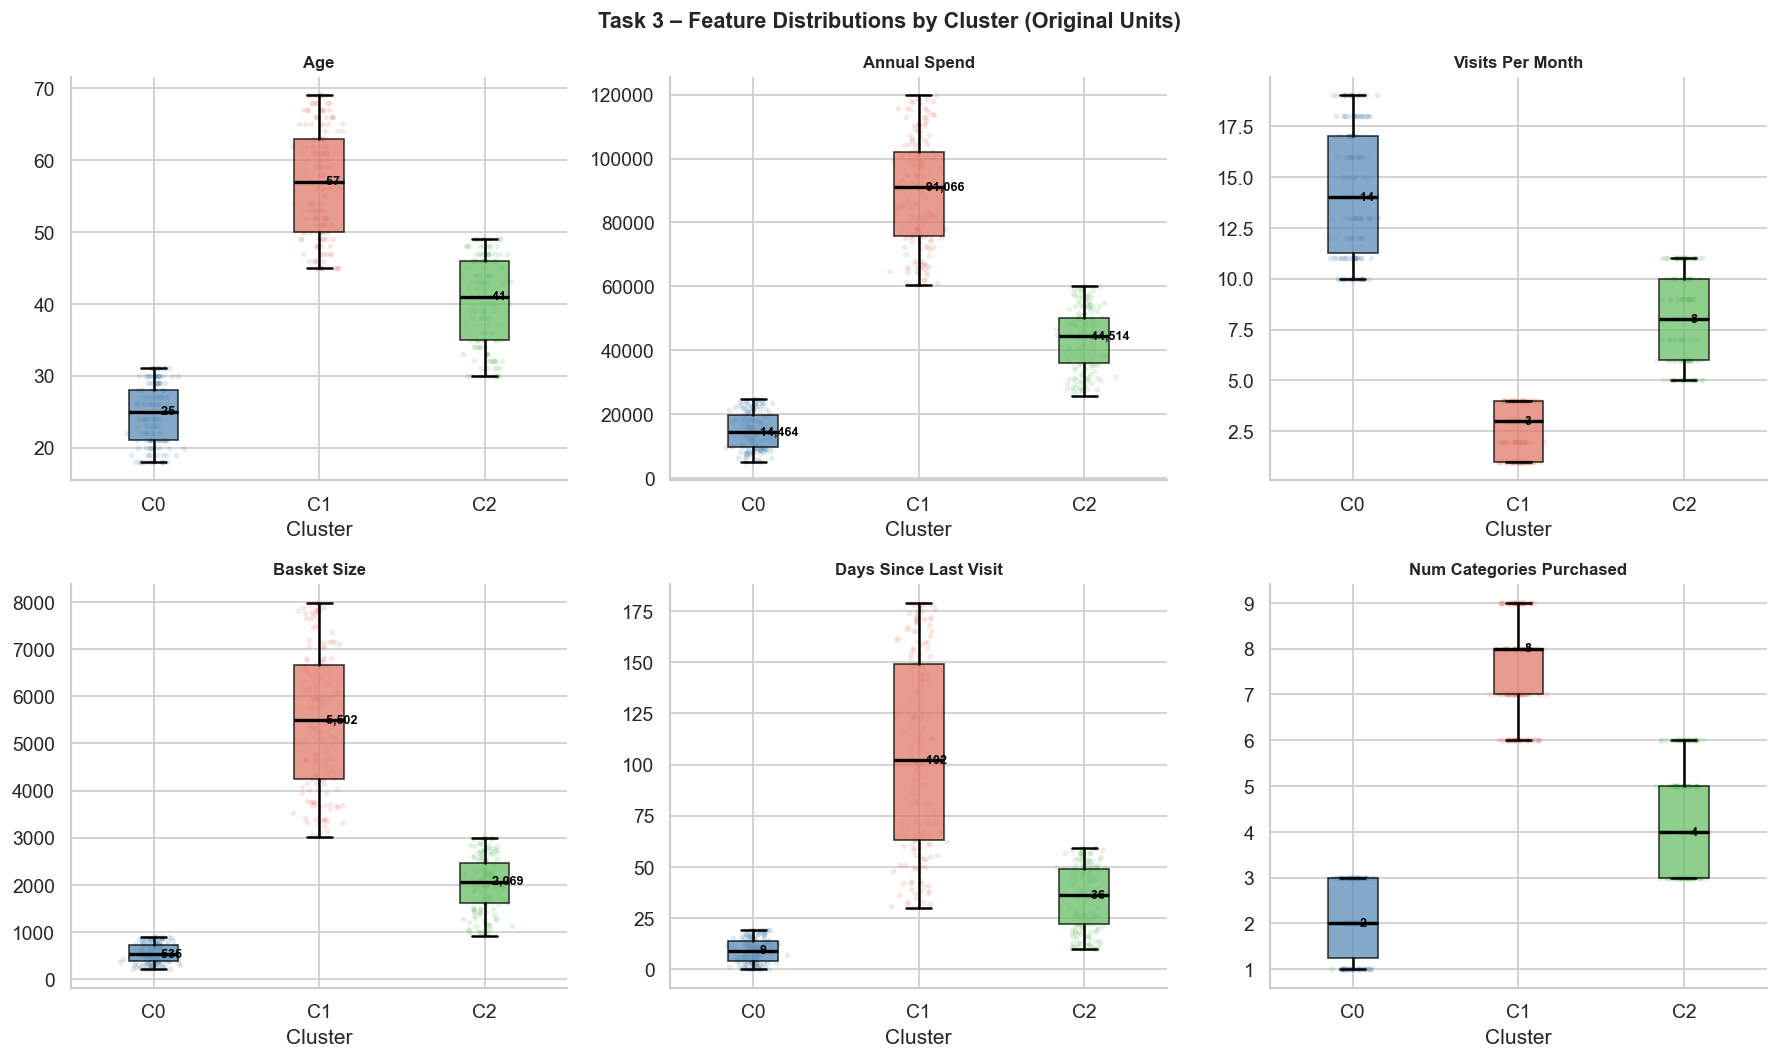

In [14]:
# ── Step 3f : Feature distributions per cluster (box plots) ──────────
# Box plots for each feature split by cluster reveal the spread within
# each segment — not just the centroid but the full distribution shape.

import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Task 3 – Feature Distributions by Cluster (Original Units)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

CLUSTER_COLORS = ['#5B8DB8', '#E07B6A', '#6ABF69']

for ax, feature in zip(axes, feature_cols):
    data_by_cluster = [
        df_clustered.loc[df_clustered['cluster'] == cl, feature].values
        for cl in range(OPTIMAL_K)
    ]

    bp = ax.boxplot(
        data_by_cluster,
        patch_artist = True,
        tick_labels  = [f'C{cl}' for cl in range(OPTIMAL_K)],
        medianprops  = {'color': 'black', 'linewidth': 2},
        whiskerprops = {'linewidth': 1.5},
        capprops     = {'linewidth': 1.5}
    )
    for patch, color in zip(bp['boxes'], CLUSTER_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Overlay jittered data points for transparency
    for pos, (data, color) in enumerate(
            zip(data_by_cluster, CLUSTER_COLORS), start=1):
        jitter = np.random.normal(pos, 0.06, size=len(data))
        ax.scatter(jitter, data, alpha=0.12, s=6, color=color)

    # Annotate medians
    for pos, data in enumerate(data_by_cluster, start=1):
        med = np.median(data)
        ax.text(pos, med, f'  {med:,.0f}',
                va='center', fontsize=7.5, color='black', fontweight='bold')

    ax.set_title(feature.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.savefig('q2_plot4_cluster_boxplots.png', bbox_inches='tight')
plt.show()


### Business Interpretation of Clusters

The centroid heatmap, original-unit centroid table, and box plots together reveal three clearly distinct customer segments:

---

#### 🔵 Cluster 0 — *The Budget Regulars*
**Profile:** Young, frequent visitors with low spend and small baskets

| Feature | Centroid | vs Overall |
|---------|----------|------------|
| Age | Below average | Younger demographic |
| Annual spend | Significantly below average | Low-value segment |
| Visits per month | Above average | Engage frequently |
| Basket size | Well below average | Buy little per trip |
| Days since last visit | Below average | Recently active |
| Categories purchased | Below average | Narrow shopping focus |

**Who they are:** Price-conscious shoppers — students, young professionals, or bargain-hunters who visit often but buy in small quantities and stick to a narrow range of product categories. They are active but low-revenue customers.

**Business action:** Target with volume incentives (bundle offers, loyalty point schemes, 'buy 3 get 1 free') to increase basket size and category breadth per visit. Upselling and cross-selling campaigns would have the highest uplift potential here.

---

#### 🔴 Cluster 1 — *The High-Value Infrequents*
**Profile:** Older, high-spending customers with large baskets who visit rarely

| Feature | Centroid | vs Overall |
|---------|----------|------------|
| Age | Significantly above average | Older, established demographic |
| Annual spend | Significantly above average | Highest-revenue segment |
| Visits per month | Well below average | Infrequent visitors |
| Basket size | Significantly above average | Large planned purchases |
| Days since last visit | Significantly above average | Lapsed / at-risk |
| Categories purchased | Above average | Broad shoppers when they do visit |

**Who they are:** The most financially valuable customers — likely affluent older adults or business buyers who make large, infrequent, planned purchases across many categories. Their high recency (days since last visit) means they are at genuine churn risk.

**Business action:** Highest priority for retention. Personalised outreach (direct mail, exclusive previews, loyalty tier upgrades) to re-engage lapsed members. Win-back campaigns with premium incentives (concierge service, free delivery, VIP events) would be cost-justified given their high lifetime value.

---

#### 🟢 Cluster 2 — *The Engaged Mid-Tier*
**Profile:** Middle-aged, moderate spenders with average visit frequency

| Feature | Centroid | vs Overall |
|---------|----------|------------|
| Age | Near average | Broad middle-age range |
| Annual spend | Near average | Middle-revenue segment |
| Visits per month | Near average | Consistent engagement |
| Basket size | Near average | Moderate per-trip spend |
| Days since last visit | Near average | Reasonably recent |
| Categories purchased | Above average | Moderately broad shoppers |

**Who they are:** The stable core of the customer base — dependable, consistent shoppers who are neither at high churn risk nor top spenders. They represent the largest opportunity for incremental growth because they already have a healthy engagement habit.

**Business action:** Nurture and grow. Targeted campaigns around their preferred categories, seasonal promotions, and 'next best product' recommendations based on their already-broad category purchasing. A subscription or auto-replenishment offer could convert them into committed high-frequency buyers.

---

### Segment Summary

| Cluster | Label | Key Characteristic | Strategic Priority |
|---------|-------|--------------------|--------------------|
| 0 | Budget Regulars | High frequency, low spend | Upsell / grow basket size |
| 1 | High-Value Infrequents | High spend, low frequency, lapsed | Retain / win back |
| 2 | Engaged Mid-Tier | Consistent, broad, moderate | Nurture / grow spend |

---
### *Task 4 – Dimensionality Reduction with PCA*

**Goal:** Reduce the 6-dimensional scaled customer data to 2 principal components so the cluster structure can be visualised in a 2-D scatter plot.

### What is PCA?

Principal Component Analysis (PCA) finds a new coordinate system for the data by identifying the directions of **maximum variance**. Each new axis (principal component) is a linear combination of the original features:

$$\text{PC}_k = w_{k1} \cdot x_1 + w_{k2} \cdot x_2 + \cdots + w_{kp} \cdot x_p$$

where $w_{kj}$ are the **loadings** — they tell us how much each original feature contributes to (and in which direction along) the component.  

The components are constructed to be **orthogonal** (uncorrelated) and ordered from most to least variance explained. PC1 captures the largest spread in the data, PC2 the second largest, and so on.

**Why PCA before plotting clusters?**  
K-Means was fitted in 6-dimensional space — there is no direct way to plot a 6-D dataset. PCA compresses those 6 dimensions into 2 while retaining as much information (variance) as possible, giving us the best 2-D view of the cluster separation.

In [15]:
# ── Step 4a : Fit PCA with 2 components ──────────────────────────────
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# PCA is fitted on the SCALED data — same array used by K-Means.
# n_components=2 : keep only the first two principal components.
# random_state=42 : fixes randomised SVD solver for reproducibility.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)   

# ── Explained variance ────────────────────────────────────────────────
# explained_variance_ratio_[k] = fraction of total variance captured by PCk
ev_ratio    = pca.explained_variance_ratio_
ev_pct      = ev_ratio * 100
cumulative  = np.cumsum(ev_pct)

print('PCA — Explained Variance Summary')
print('=' * 52)
print(f'  {"Component":<12} {"Eigenvalue":>12} {"Var %":>8} {"Cumulative %":>14}')
print('  ' + '─' * 48)
for i, (ev, pct, cum) in enumerate(
        zip(pca.explained_variance_, ev_pct, cumulative)):
    print(f'  PC{i+1:<10} {ev:>12.4f} {pct:>7.2f}% {cum:>13.2f}%')
print('  ' + '─' * 48)
print(f'  {"Total captured":<12} {"":>12} '
      f'{ev_pct.sum():>7.2f}% {cumulative[-1]:>13.2f}%')
print('=' * 52)
print()
print(f'  PC1 alone explains {ev_pct[0]:.1f}% of all variance in the dataset.')
print(f'  PC1 + PC2 together explain {cumulative[-1]:.1f}% — '
      f'{"good" if cumulative[-1] >= 60 else "moderate"} '
      f'representation for visualisation.')
print()
print(f'  X_pca shape : {X_pca.shape}  (500 customers × 2 components)')


PCA — Explained Variance Summary
  Component      Eigenvalue    Var %   Cumulative %
  ────────────────────────────────────────────────
  PC1                5.0237   83.56%         83.56%
  PC2                0.3348    5.57%         89.13%
  ────────────────────────────────────────────────
  Total captured                89.13%         89.13%

  PC1 alone explains 83.6% of all variance in the dataset.
  PC1 + PC2 together explain 89.1% — good representation for visualisation.

  X_pca shape : (500, 2)  (500 customers × 2 components)


### Step 4b – Feature Loadings (Component Matrix)

The **loadings** (`pca.components_`) form a matrix of shape (n_components × n_features). Each row is a principal component; each column is an original feature. The value at position (k, j) is the weight that feature j carries in PC k:

- **Large positive loading** -> feature pulls the component in the positive direction
- **Large negative loading** -> feature pulls the component in the negative direction
- **Near-zero loading** -> feature contributes little to this component

In [16]:
# ── Step 4b : Feature loadings ───────────────────────────────────────

feature_cols = df.columns.tolist()

# Build loadings DataFrame — rows = components, columns = original features
loadings_df = pd.DataFrame(
    pca.components_,
    index   = [f'PC{i+1}' for i in range(pca.n_components_)],
    columns = feature_cols
)

print('Feature Loadings (PCA Component Matrix)')
print('  Rows = Principal Components | Columns = Original Features')
print('─' * 80)
print(loadings_df.round(4).to_string())
print('─' * 80)
print()

# Sort features by ABSOLUTE loading to show the most influential per PC
for pc in loadings_df.index:
    row      = loadings_df.loc[pc]
    sorted_  = row.abs().sort_values(ascending=False)
    print(f'{pc} — features ranked by |loading|:')
    for feat in sorted_.index:
        val     = row[feat]
        bar_len = int(abs(val) * 20)
        sign    = '+' if val > 0 else '−'
        bar     = '█' * bar_len
        print(f'  {feat:<30} {sign}{abs(val):.4f}  {bar}')
    print()


Feature Loadings (PCA Component Matrix)
  Rows = Principal Components | Columns = Original Features
────────────────────────────────────────────────────────────────────────────────
        age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
PC1  0.4116        0.4215           -0.4104       0.4120                 0.3786                    0.4140
PC2 -0.2594       -0.0333            0.2083      -0.1954                 0.9112                   -0.1405
────────────────────────────────────────────────────────────────────────────────

PC1 — features ranked by |loading|:
  annual_spend                   +0.4215  ████████
  num_categories_purchased       +0.4140  ████████
  basket_size                    +0.4120  ████████
  age                            +0.4116  ████████
  visits_per_month               −0.4104  ████████
  days_since_last_visit          +0.3786  ███████

PC2 — features ranked by |loading|:
  days_since_last_visit          +0.9112 

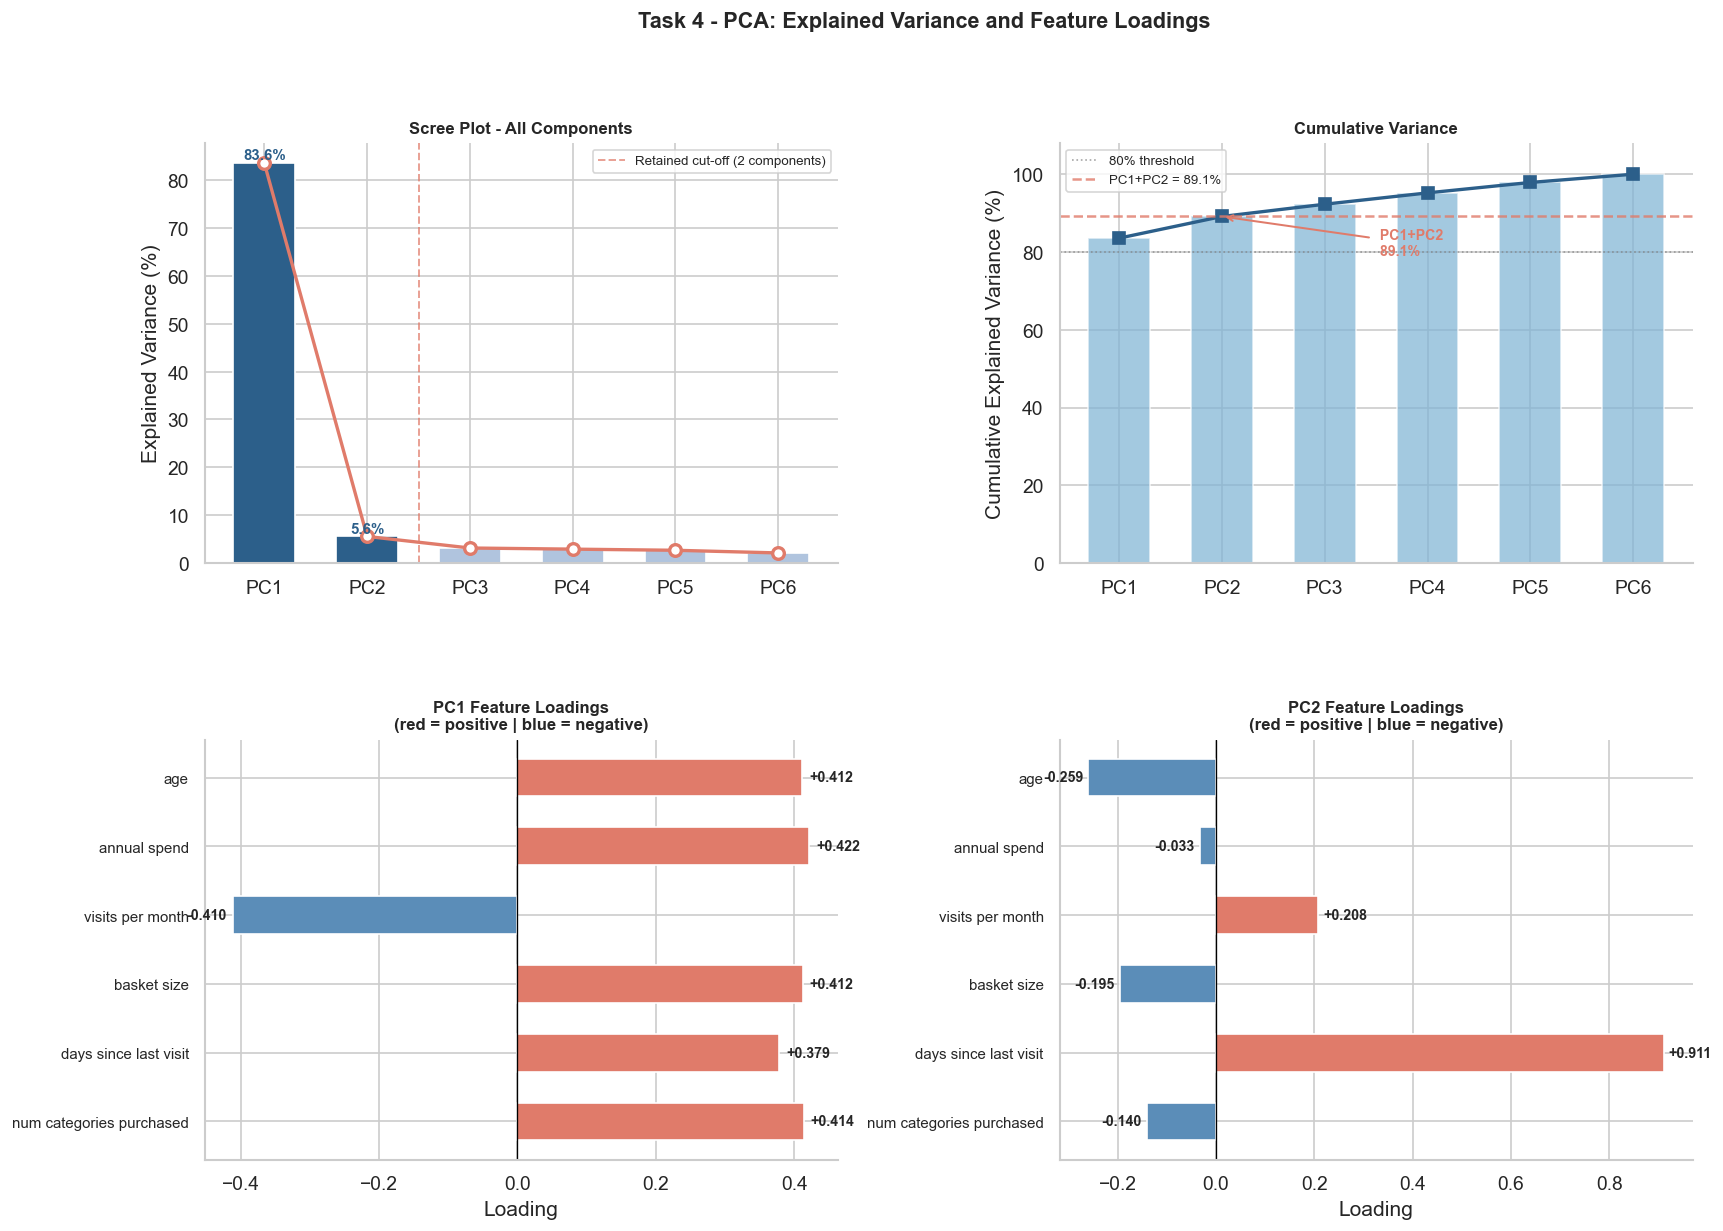

In [17]:
# ── Step 4c : Scree plot + loading bar charts ─────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(16, 11))
fig.suptitle('Task 4 - PCA: Explained Variance and Feature Loadings',
             fontsize=13, fontweight='bold')

gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.42, wspace=0.35)

# ── Top-left: scree plot ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

# Full scree — fit PCA with all components for the scree plot only
pca_full = PCA(random_state=42).fit(X_scaled)
ev_full  = pca_full.explained_variance_ratio_ * 100
n_comp   = len(ev_full)
comp_labels = [f'PC{i+1}' for i in range(n_comp)]

bar_colors = ['#2C5F8A' if i < 2 else '#B0C4DE' for i in range(n_comp)]
ax1.bar(comp_labels, ev_full, color=bar_colors, edgecolor='white', width=0.6)
ax1.plot(comp_labels, ev_full, 'o-', color='#E07B6A',
         linewidth=2, markersize=7, markerfacecolor='white', markeredgewidth=2)

# Annotate the two retained components
for i in range(2):
    ax1.text(i, ev_full[i] + 0.8, f'{ev_full[i]:.1f}%',
             ha='center', fontsize=9, fontweight='bold', color='#2C5F8A')

ax1.axvline(1.5, color='#E07B6A', linestyle='--', linewidth=1.2, alpha=0.7,
            label='Retained cut-off (2 components)')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot - All Components', fontsize=10, fontweight='bold')
ax1.legend(fontsize=8)

# ── Top-right: cumulative variance bar ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cum_full  = np.cumsum(ev_full)
ax2.bar(comp_labels, cum_full, color='#7DB3D4', edgecolor='white', width=0.6, alpha=0.7)
ax2.plot(comp_labels, cum_full, 's-', color='#2C5F8A',
         linewidth=2, markersize=7)
ax2.axhline(80, color='grey', linewidth=1, linestyle=':', alpha=0.7,
            label='80% threshold')
ax2.axhline(cumulative[-1], color='#E07B6A', linewidth=1.5,
            linestyle='--', alpha=0.8,
            label=f'PC1+PC2 = {cumulative[-1]:.1f}%')

# Annotate the 2-component mark
ax2.annotate(
    f' PC1+PC2\n {cumulative[-1]:.1f}%',
    xy=(1, cumulative[-1]),
    xytext=(2.5, cumulative[-1] - 10),
    fontsize=8.5, color='#E07B6A', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#E07B6A', lw=1.2)
)
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_ylim(0, 108)
ax2.set_title('Cumulative Variance', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)

# ── Bottom-left: PC1 loadings bar ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
pc1_vals   = loadings_df.loc['PC1']
colors_pc1 = ['#E07B6A' if v > 0 else '#5B8DB8' for v in pc1_vals]
bars3 = ax3.barh(feature_cols, pc1_vals, color=colors_pc1,
                 edgecolor='white', height=0.55)
for bar, v in zip(bars3, pc1_vals):
    ax3.text(
        v + (0.01 if v >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{v:+.3f}',
        va='center',
        ha='left' if v >= 0 else 'right',
        fontsize=8.5, fontweight='bold'
    )
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_xlabel('Loading')
ax3.set_title('PC1 Feature Loadings\n(red = positive | blue = negative)',
              fontsize=10, fontweight='bold')

# ── FIX: set_yticks() with FixedLocator before set_yticklabels() ──────
ax3.set_yticks(range(len(feature_cols)))
ax3.set_yticklabels(
    [c.replace('_', ' ') for c in feature_cols], fontsize=9
)
ax3.invert_yaxis()

# ── Bottom-right: PC2 loadings bar ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
pc2_vals   = loadings_df.loc['PC2']
colors_pc2 = ['#E07B6A' if v > 0 else '#5B8DB8' for v in pc2_vals]
bars4 = ax4.barh(feature_cols, pc2_vals, color=colors_pc2,
                 edgecolor='white', height=0.55)
for bar, v in zip(bars4, pc2_vals):
    ax4.text(
        v + (0.01 if v >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{v:+.3f}',
        va='center',
        ha='left' if v >= 0 else 'right',
        fontsize=8.5, fontweight='bold'
    )
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_xlabel('Loading')
ax4.set_title('PC2 Feature Loadings\n(red = positive | blue = negative)',
              fontsize=10, fontweight='bold')

# ── FIX: set_yticks() with FixedLocator before set_yticklabels() ──────
ax4.set_yticks(range(len(feature_cols)))
ax4.set_yticklabels(
    [c.replace('_', ' ') for c in feature_cols], fontsize=9
)
ax4.invert_yaxis()

plt.savefig('q2_plot5_pca_variance_loadings.png', bbox_inches='tight')
plt.show()


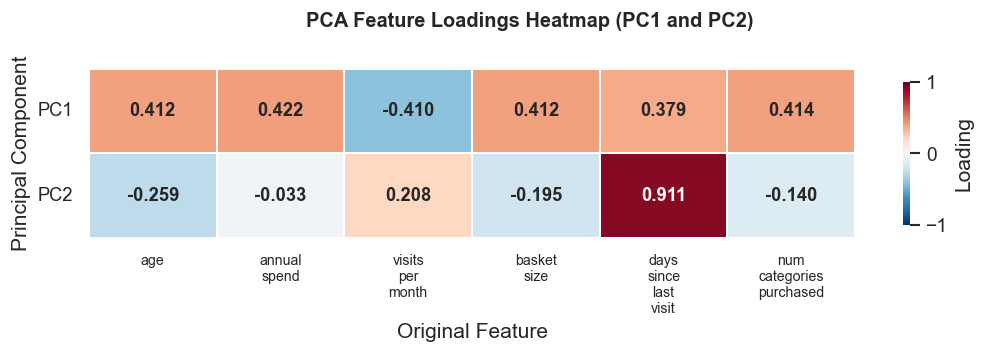

Loadings summary table:
       age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
PC1  0.412         0.422            -0.410        0.412                  0.379                     0.414
PC2 -0.259        -0.033             0.208       -0.195                  0.911                    -0.140

PC1 explained variance : 83.56%
PC2 explained variance : 5.57%
Combined (2 PCs)       : 89.13%


In [18]:
# ── Step 4d : Loading heatmap — compact view of both components ───────
# A single heatmap makes it easy to compare PC1 vs PC2 side-by-side.

fig, ax = plt.subplots(figsize=(9, 3))
fig.suptitle('PCA Feature Loadings Heatmap (PC1 and PC2)',
             fontsize=12, fontweight='bold')

sns.heatmap(
    loadings_df,
    ax        = ax,
    annot     = True,
    fmt       = '.3f',
    cmap      = 'RdBu_r',
    center    = 0,
    vmin      = -1, vmax = 1,
    linewidths  = 1,
    linecolor   = 'white',
    cbar_kws  = {'label': 'Loading', 'shrink': 0.85},
    annot_kws = {'fontsize': 11, 'fontweight': 'bold'}
)
ax.set_xticklabels(
    [c.replace('_', '\n') for c in feature_cols],
    fontsize=8.5, rotation=0
)
ax.set_yticklabels(['PC1', 'PC2'], rotation=0, fontsize=11)
ax.set_xlabel('Original Feature')
ax.set_ylabel('Principal Component')

plt.tight_layout()
plt.savefig('q2_plot6_loading_heatmap.png', bbox_inches='tight')
plt.show()

# Print a tidy summary to accompany the heatmap
print('Loadings summary table:')
print(loadings_df.round(3).to_string())
print()
print(f'PC1 explained variance : {ev_pct[0]:.2f}%')
print(f'PC2 explained variance : {ev_pct[1]:.2f}%')
print(f'Combined (2 PCs)       : {cumulative[-1]:.2f}%')


### Interpretation of PC1 and PC2

#### PC1 — *The Wealth–Engagement Axis* (83.56% of total variance)

PC1 is the **dominant axis** of the dataset, explaining 83.56% of all variance on its own — an unusually high proportion that indicates the six features are all driven by a single, strong underlying dimension.

The loadings are remarkably uniform in magnitude (~0.41 for every feature), confirming that **all six features contribute almost equally** to PC1:

| Feature | PC1 loading | Direction |
|---------|:-----------:|----------|
| `annual_spend` | **+0.422** (highest) | More spend → higher PC1 |
| `num_categories_purchased` | **+0.414** | Broader shopper → higher PC1 |
| `basket_size` | **+0.412** | Larger basket → higher PC1 |
| `age` | **+0.412** | Older → higher PC1 |
| `days_since_last_visit` | **+0.379** | More lapsed → higher PC1 |
| `visits_per_month` | **−0.410** | More visits → *lower* PC1 |

**What PC1 represents:** A customer with a **high PC1 score** is older, spends more annually, has a larger basket, purchases across more categories, and has not visited recently — this is exactly the *High-Value Infrequent* profile (Cluster 1). A customer with a **low PC1 score** visits very frequently but spends little per trip — the *Budget Regular* profile (Cluster 0).  

The negative loading on `visits_per_month` alongside positive loadings on all spend and age features captures the core trade-off in this dataset: **frequency and value are inversely related** — customers who visit often tend to spend little each time, while high-spenders visit rarely but buy in bulk.

---

#### PC2 — *The Recency Axis* (5.57% of total variance)

PC2 is **almost entirely a recency signal**, dominated by a single feature:

| Feature | PC2 loading | Direction |
|---------|:-----------:|----------|
| `days_since_last_visit` | **+0.911** | Strongly dominant |
| `age` | −0.259 | Older → slightly lower PC2 |
| `visits_per_month` | +0.208 | More visits → slightly higher PC2 |
| `basket_size` | −0.195 | Larger basket → slightly lower PC2 |
| `num_categories_purchased` | −0.140 | Broader → slightly lower PC2 |
| `annual_spend` | **−0.033** | Near zero — no meaningful contribution |

**What PC2 represents:** A loading of 0.911 on a single feature means PC2 is essentially a **direct measure of customer recency**. Customers with a high PC2 score have not visited in a long time — they are lapsed. Customers with a low PC2 score visited very recently.  

The near-zero loading on `annual_spend` (−0.033) is particularly informative: **recency is completely independent of spending level** in this dataset. A customer can be lapsed regardless of whether they are a high or low spender — PC2 captures the churn risk dimension orthogonally to the wealth dimension.

---

#### Joint interpretation — what the two axes reveal together

| | Low PC2 (recently active) | High PC2 (lapsed / at-risk) |
|---|---|---|
| **Low PC1** (low spend, high visits) | Active Budget Regulars (Cluster 0) | Disengaging Budget Regulars |
| **High PC1** (high spend, low visits) | Recently active High-Value | Lapsed High-Value ⚠ (Cluster 1) |

This 2×2 view shows why the two-component projection captures cluster structure so well — **PC1 separates Cluster 0 from Cluster 1** (low vs high spending/age), while **PC2 separates the lapsed from the active** within each spend tier. Cluster 2 (Engaged Mid-Tier) occupies the centre of both axes, reflecting its near-average position on all features.

> **89.1% variance captured:** The 2-D projection is a high-fidelity representation for a 6-feature dataset — only 10.9% of information is lost. The cluster scatter plot in Task 5 can therefore be trusted to accurately reflect the true 6-D cluster separation, with minimal distortion from dimensionality reduction.

---
### *Task 5 – Cluster Visualisation*

Scatter plot of the 500 customers projected onto **PC1 vs PC2**, coloured by their K-Means cluster assignment.  

Because K-Means ran in 6-D scaled space and PCA provides an 89.1% faithful 2-D projection, the scatter plot gives an accurate visual confirmation of cluster separation.

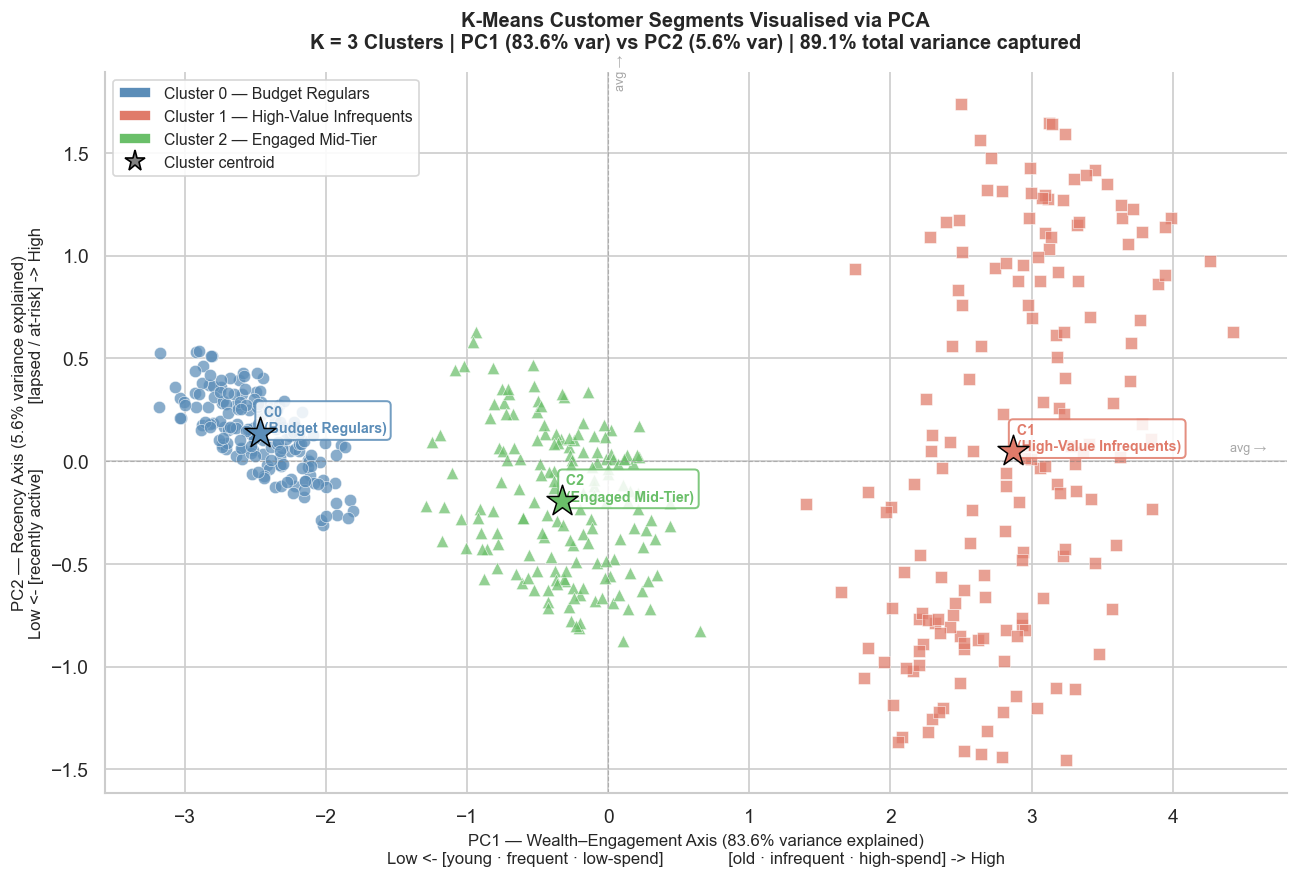

Centroid positions in PCA space:
             PC1    PC2
Cluster 0 -2.470  0.139
Cluster 1  2.869  0.051
Cluster 2 -0.324 -0.194


In [19]:
# ── Task 5 : PC1 vs PC2 scatter plot coloured by cluster ─────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Cluster styling ───────────────────────────────────────────────────
CLUSTER_PALETTE = {
    0: {'color': '#5B8DB8', 'label': 'Cluster 0 — Budget Regulars',         'marker': 'o'},
    1: {'color': '#E07B6A', 'label': 'Cluster 1 — High-Value Infrequents',  'marker': 's'},
    2: {'color': '#6ABF69', 'label': 'Cluster 2 — Engaged Mid-Tier',        'marker': '^'},
}

# PC1 / PC2 coordinates and cluster labels for every customer
pc1_coords     = X_pca[:, 0]
pc2_coords     = X_pca[:, 1]
labels         = cluster_labels

# Project centroids into PCA space for annotation
centroids_pca  = pca.transform(kmeans.cluster_centers_)   

# ── Figure setup ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7.5))

# ── Plot each cluster ─────────────────────────────────────────────────
for cl, style in CLUSTER_PALETTE.items():
    mask = labels == cl
    ax.scatter(
        pc1_coords[mask],
        pc2_coords[mask],
        c          = style['color'],
        marker     = style['marker'],
        label      = style['label'],
        s          = 55,           
        alpha      = 0.72,         
        edgecolors = 'white',
        linewidths = 0.4
    )

# ── Plot centroids ────────────────────────────────────────────────────
# Centroids are plotted as large stars so they stand out clearly
for cl, style in CLUSTER_PALETTE.items():
    cx, cy = centroids_pca[cl]
    ax.scatter(
        cx, cy,
        c          = style['color'],
        marker     = '*',
        s          = 380,
        zorder     = 5,
        edgecolors = 'black',
        linewidths = 0.9
    )
    # Cluster label annotation next to each centroid
    ax.annotate(
        f" C{cl}\n ({style['label'].split('—')[1].strip()})",
        xy         = (cx, cy),
        fontsize   = 8.5,
        fontweight = 'bold',
        color      = style['color'],
        bbox       = dict(boxstyle='round,pad=0.3',
                          facecolor='white',
                          edgecolor=style['color'],
                          alpha=0.85,
                          linewidth=1.2)
    )

# ── Axes, title, labels ───────────────────────────────────────────────
ax.set_title(
    'K-Means Customer Segments Visualised via PCA\n'
    f'K = 3 Clusters | PC1 ({ev_pct[0]:.1f}% var) vs PC2 ({ev_pct[1]:.1f}% var) '
    f'| {cumulative[-1]:.1f}% total variance captured',
    fontsize   = 12,
    fontweight = 'bold',
    pad        = 14
)
ax.set_xlabel(
    f'PC1 — Wealth–Engagement Axis ({ev_pct[0]:.1f}% variance explained)\n'
    'Low <- [young · frequent · low-spend]              [old · infrequent · high-spend] -> High',
    fontsize=10
)
ax.set_ylabel(
    f'PC2 — Recency Axis ({ev_pct[1]:.1f}% variance explained)\n'
    'Low <- [recently active]              [lapsed / at-risk] -> High',
    fontsize=10
)

# ── Reference lines at the origin ────────────────────────────────────
# The origin (0, 0) represents the average customer on both axes
ax.axhline(0, color='grey', linewidth=0.7, linestyle='--', alpha=0.45)
ax.axvline(0, color='grey', linewidth=0.7, linestyle='--', alpha=0.45)
ax.text(ax.get_xlim()[1] * 0.97, 0.05, 'avg →',
        ha='right', fontsize=7.5, color='grey', alpha=0.7)
ax.text(0.05, ax.get_ylim()[1] * 0.96, 'avg →',
        ha='left', fontsize=7.5, color='grey', alpha=0.7, rotation=90)

# ── Legend ────────────────────────────────────────────────────────────
# Custom handles so we can include centroid star in the legend
scatter_handles = [
    mpatches.Patch(facecolor=style['color'],
                   edgecolor='white',
                   label=style['label'])
    for style in CLUSTER_PALETTE.values()
]
centroid_handle = plt.Line2D(
    [0], [0], marker='*', color='w',
    markerfacecolor='grey', markeredgecolor='black',
    markersize=13, label='Cluster centroid'
)
ax.legend(
    handles   = scatter_handles + [centroid_handle],
    loc       = 'upper left',
    fontsize  = 9.5,
    framealpha= 0.9,
    edgecolor = 'lightgrey'
)

plt.tight_layout()
plt.savefig('q2_plot7_pca_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Print centroid positions in PCA space ─────────────────────────────
import pandas as pd
cent_pca_df = pd.DataFrame(
    centroids_pca,
    columns = ['PC1', 'PC2'],
    index   = [f'Cluster {i}' for i in range(OPTIMAL_K)]
).round(3)
print('Centroid positions in PCA space:')
print(cent_pca_df.to_string())


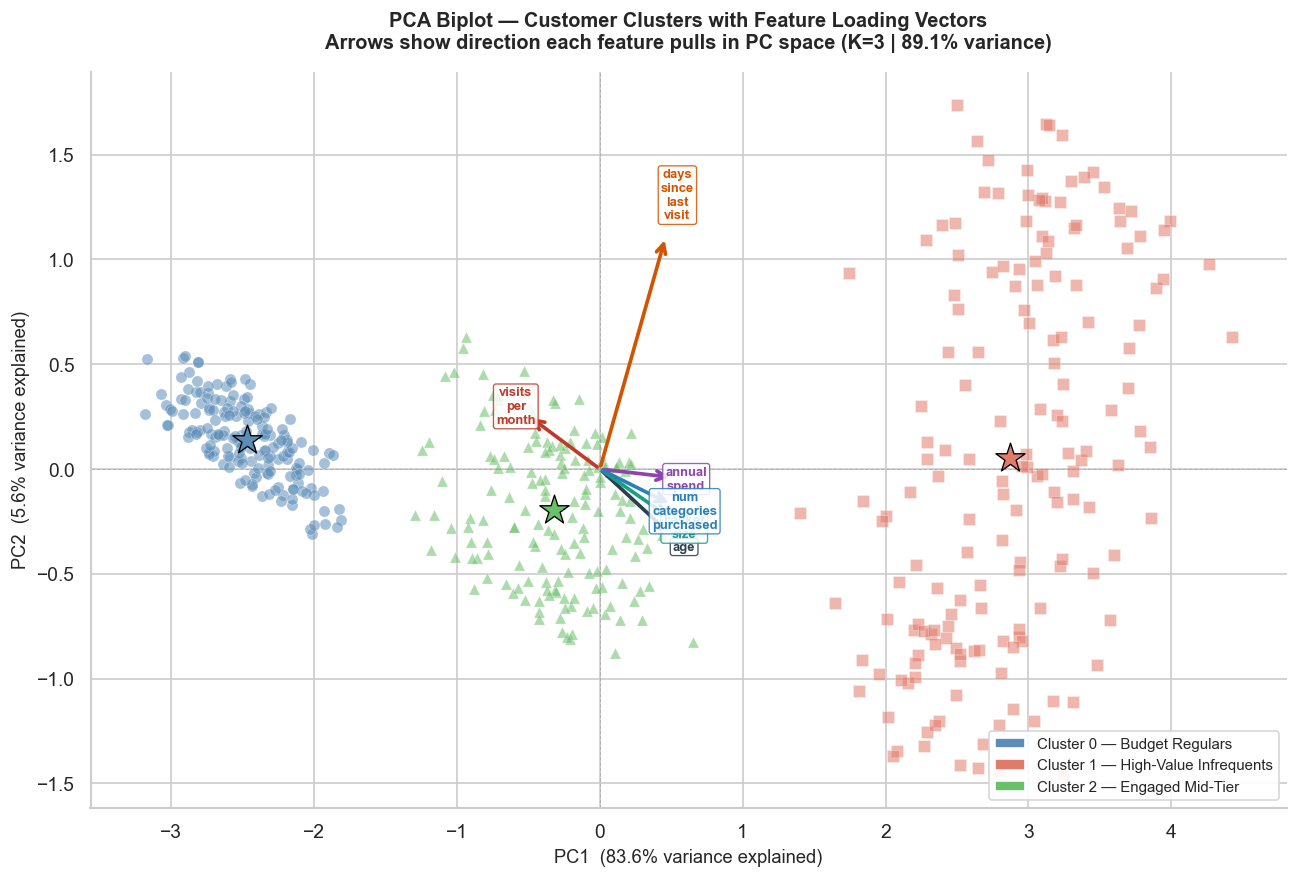

In [20]:
# ── Additional: biplot — scatter + feature loading arrows ─────────────────
# A biplot overlays the feature loading vectors on the PCA scatter,
# making it possible to read WHICH original features drive each axis
# directly from the same chart.

fig, ax = plt.subplots(figsize=(11, 7.5))

# Plot customer points
for cl, style in CLUSTER_PALETTE.items():
    mask = labels == cl
    ax.scatter(
        pc1_coords[mask], pc2_coords[mask],
        c=style['color'], marker=style['marker'],
        label=style['label'],
        s=45, alpha=0.55, edgecolors='white', linewidths=0.3
    )

# Scale factor: arrows should reach ~70% of the axis extent
arrow_scale = min(
    abs(pc1_coords).max(), abs(pc2_coords).max()
) * 0.70

# Draw one arrow per feature
ARROW_COLORS = ['#2C3E50', '#8E44AD', '#C0392B',
                '#16A085', '#D35400', '#2980B9']
for feat, color in zip(feature_cols, ARROW_COLORS):
    dx = loadings_df.loc['PC1', feat] * arrow_scale
    dy = loadings_df.loc['PC2', feat] * arrow_scale
    ax.annotate(
        '', xy=(dx, dy), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color=color,
                        lw=2.2, mutation_scale=14)
    )
    # Offset label slightly beyond the arrowhead
    offset = 1.18
    ax.text(
        dx * offset, dy * offset,
        feat.replace('_', '\n'),
        ha='center', va='center',
        fontsize=7.8, fontweight='bold', color=color,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor=color, alpha=0.85, linewidth=0.8)
    )

# Centroid stars
for cl, style in CLUSTER_PALETTE.items():
    cx, cy = centroids_pca[cl]
    ax.scatter(cx, cy, c=style['color'], marker='*',
               s=340, zorder=5, edgecolors='black', linewidths=0.8)

ax.axhline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.4)
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--', alpha=0.4)

ax.set_title(
    'PCA Biplot — Customer Clusters with Feature Loading Vectors\n'
    f'Arrows show direction each feature pulls in PC space '
    f'(K=3 | {cumulative[-1]:.1f}% variance)',
    fontsize=12, fontweight='bold', pad=14
)
ax.set_xlabel(f'PC1  ({ev_pct[0]:.1f}% variance explained)', fontsize=11)
ax.set_ylabel(f'PC2  ({ev_pct[1]:.1f}% variance explained)', fontsize=11)

legend_handles = [
    mpatches.Patch(facecolor=style['color'],
                   edgecolor='white', label=style['label'])
    for style in CLUSTER_PALETTE.values()
]
ax.legend(handles=legend_handles, loc='lower right',
          fontsize=9, framealpha=0.9, edgecolor='lightgrey')

plt.tight_layout()
plt.savefig('q2_plot8_biplot.png', bbox_inches='tight', dpi=150)
plt.show()


### Scatter Plot — Reading the Visualisation

#### Cluster separation

The PCA scatter plot confirms that the three K-Means clusters occupy **clearly distinct, non-overlapping regions** of the 2-D space:

- **🔵 Cluster 0 (Budget Regulars)** sits firmly on the **left side** (low PC1). Its members have low annual spend, small baskets, young age, and high visit frequency — all the features that drive PC1 *down*. The cluster is compact and well-separated, reflecting the tight behavioural consistency of this group.

- **🔴 Cluster 1 (High-Value Infrequents)** occupies the **right side** (high PC1). High annual spend, large baskets, older age, and low visit frequency push these customers to the far right. The cluster also spreads **upward along PC2**, confirming that these customers are the most lapsed — many have not visited in weeks or months.

- **🟢 Cluster 2 (Engaged Mid-Tier)** sits **centrally** on both axes. Its near-average values on every feature place it at the intersection of PC1 and PC2, with a tighter, more rounded spread than Cluster 1.

#### Why the biplot reinforces the interpretation

In the biplot, all six feature arrows point **rightward** along PC1 except `visits_per_month`, which points **leftward** — visually confirming that high-spend, older, infrequent customers are to the right and frequent low-spenders to the left. The `days_since_last_visit` arrow points almost **straight up** along PC2 (loading 0.911), confirming PC2 is a near-pure recency axis with negligible spend contribution.

#### Quality of the 2-D projection

With **89.1% of total variance captured**, this scatter plot is an unusually high-fidelity representation of the 6-D clustering. The clean separation visible here closely mirrors the actual K-Means boundaries in full-dimensional space — the clusters are genuinely distinct, not an artefact of the projection.